In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np

from func_for_fig3D import *
import adaptive
adaptive.notebook_extension();


ModuleNotFoundError: No module named 'tai_localizer'

In [3]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [27]:
# lattice params
system_size = 10

# sys params
A = 1
MJ = 2.3
onsite_disorder = 0 
num_realizations = 1
seed = 0
bond_lengthscale = 1 / system_size
bond_power = 1 / system_size

# localizer params
kappa = 2
E0 = 0

# function
params_obs_3D(
    system_size=system_size,
    MJ=MJ,
    A=A,
    onsite_disorder=onsite_disorder,
    disorder_average=num_realizations,
    bond_lengthscale=bond_lengthscale,
    bond_power=bond_power,
    kappa_spec=kappa,
    E0=E0,
    sigma=0.,
    kappa_shift=0,
    beta=1,
    )


np.float64(-1.0)

# 2a

In [7]:
# plot params
MJ_bounds = (0, 4)
disorder_bounds = (0, 12)
def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 5000  # continue until 1000 points
n_task = 8

# adaptive
f = lambda dis_MJ: params_obs_3D(
    system_size=system_size,
    MJ=dis_MJ[0],
    A=A,
    onsite_disorder=dis_MJ[1],
    disorder_average=num_realizations,
    bond_lengthscale=bond_lengthscale,
    bond_power=bond_power,
    kappa_spec=kappa,
    E0=E0,
    sigma=0.,
    kappa_shift=0,
    beta=1,
    )

learner_dis = adaptive.Learner2D(
    f,
    bounds=[
        MJ_bounds,
        disorder_bounds,
    ],
)


runner_dis = adaptive.Runner(
    learner_dis,
    goal=goal,
    ntasks=n_task,
)

runner_dis.live_info()

# 2b

In [59]:
# plot params
MJ_bounds = (0, 4)
sigma_bounds = (0, 2 / system_size)

def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 5000  # continue until 1000 points
n_task = 8

# adaptive
f = lambda sigma_MJ: params_obs_3D(
    system_size=system_size,
    MJ=sigma_MJ[0],
    A=A,
    onsite_disorder=0,
    disorder_average=1,
    bond_lengthscale=bond_lengthscale,
    bond_power=bond_power,
    kappa_spec=kappa,
    E0=E0,
    sigma=sigma_MJ[1],
    kappa_shift=0,
    beta=1,
    )

learner_sigma = adaptive.Learner2D(
    f,
    bounds=[
        MJ_bounds,
        sigma_bounds,
    ],
)


runner_sigma = adaptive.Runner(
    learner_sigma,
    goal=goal,
    ntasks=n_task,
)

runner_sigma.live_info()

# plot

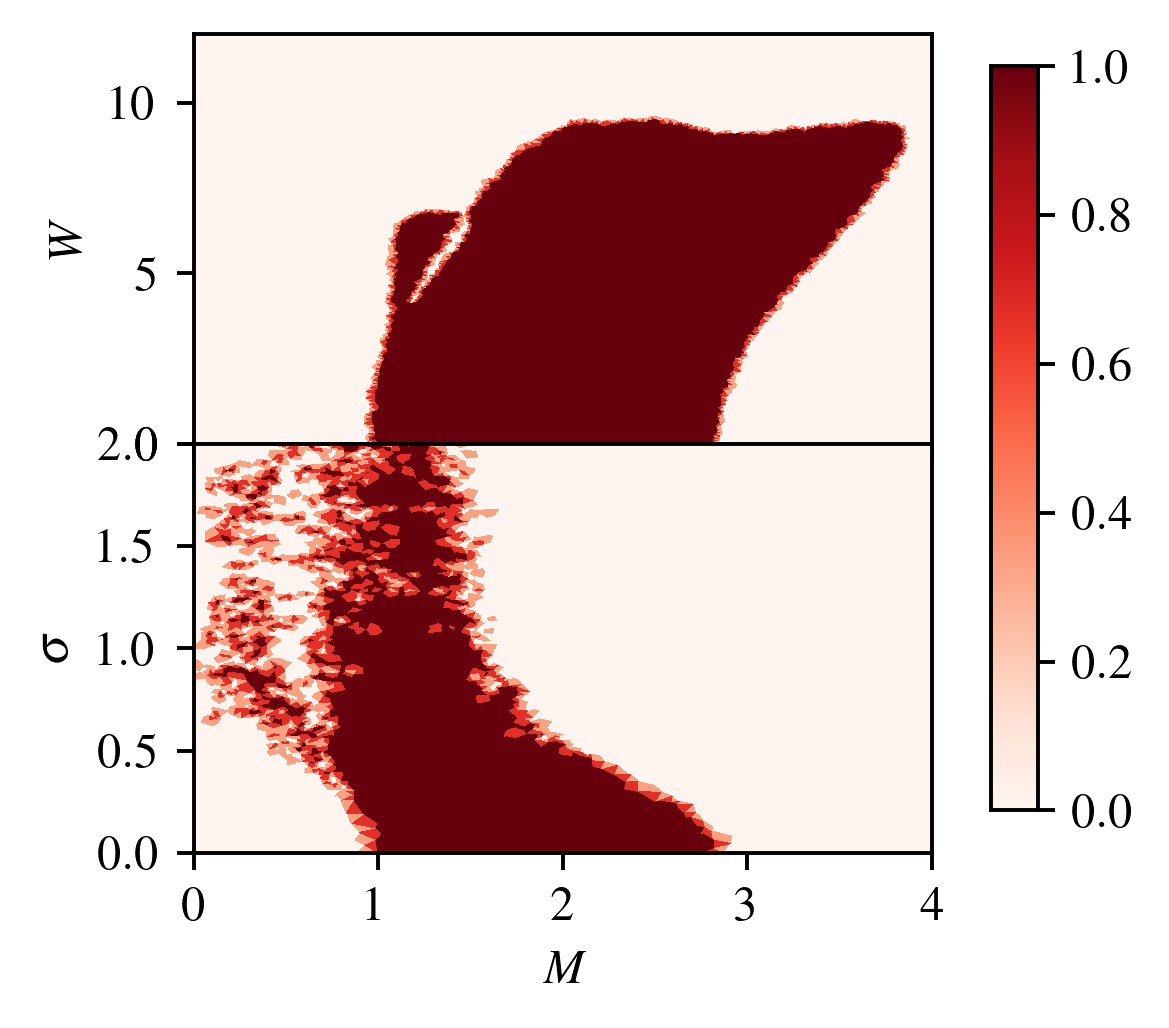

In [108]:
specs = np.array([learner_dis.data[k] for k in learner_dis.data.keys()])
positions = np.array([k for k in learner_dis.data.keys()])
fig, ax = plt.subplots(
    2, 1, figsize=(aps_halfwidth, 0.9 * aps_halfwidth), dpi=350, sharex=True
)
plt.subplots_adjust(hspace=0)

######### 2a #########

specs = np.array([learner_dis.data[k] for k in learner_dis.data.keys()])
positions = np.array([k for k in learner_dis.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)


p1 = ax[0].tripcolor(
    positions[:, 0],
    positions[:, 1],
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)
ax[0].set_xlim(MJ_bounds)
ax[0].set_ylim(disorder_bounds)
ax[0].set_ylabel(r"$W$")




########### 2b #########

######### 2b #########
specs = np.array([learner_sigma.data[k] for k in learner_sigma.data.keys()])
positions = np.array([k for k in learner_sigma.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)

p2 = ax[1].tripcolor(
    positions[:, 0],
    positions[:, 1] * system_size,
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)
ax[1].set_xlim(MJ_bounds)
ax[1].set_ylim(np.array(sigma_bounds) * system_size)
# ax[1].set_yticks([0, 0.05, 0.1, 0.15])
ax[1].set_xlabel(r"$M$")
ax[1].set_ylabel(r"$\sigma$")




########### colorbar ###########
fig.subplots_adjust(right=0.75)
cbar_ax = fig.add_axes([0.8, 0.15, 0.04, 0.7])
fig.colorbar(p1, cax=cbar_ax)   

 

